<a href="https://colab.research.google.com/github/giuspugl/astrophysics_lab/blob/main/cosmo_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install classy
!pip install healpy

In [26]:

import classy

cosmo  = classy.Class()

####################################################
#
# Cosmological parameters and other CLASS parameters
#
####################################################
input = {# LambdaCDM parameters (Planck 18 + lensing + BAO bestfit)
        'omega_b':2.255065e-02,
        'omega_cdm':1.193524e-01,
        'H0':6.776953e+01,
        'A_s':2.123257e-09,
        'n_s':9.686025e-01,
        'z_reio':8.227371e+00,
        # other fixed parameters
        'N_ur':2.0328,
        'N_ncdm':1,
        'm_ncdm':0.06,
        'T_ncdm':0.71611,
        # settings for the output quantites
        'output':'mPk, tCl, pCl, lCl',
        'lensing':'yes',
        'P_k_max_h/Mpc':1.0,
        'non_linear':'halofit','z_max_pk':1.
        }
cosmo.set(input)
cosmo.compute()




In [4]:
cosmo.set_baseline('planck2018')
cosmo.compute()

In [5]:
cosmo.pars

{'omega_b': 0.02237064,
 'omega_cdm': 0.1214344,
 'H0': 66.85836,
 'A_s': 2.112203e-09,
 'n_s': 0.96228,
 'z_reio': 7.7957,
 'N_ur': 2.0328,
 'N_ncdm': 1,
 'm_ncdm': 0.06,
 'T_ncdm': 0.71611,
 'output': 'mPk, tCl, pCl, lCl',
 'lensing': 'yes',
 'P_k_max_h/Mpc': 1.0,
 'non_linear': 'halofit'}

In [7]:

# get lesned C_l spectra
cls = cosmo.lensed_cl(2500)
# To check the format of cls
cls.keys()


dict_keys(['tt', 'ee', 'te', 'bb', 'pp', 'tp', 'ell'])

In [8]:
# get multipoles l
ll = cls['ell']
# get CMB temperature spectrum C_l^TT
clTT = cls['tt']
# get CMB polarisation spectrum C_l^EE
clEE = cls['ee']
# get CMB polarisation spectrum C_l^EE

clBB= cls['bb']

In [9]:
# uncomment to get plots displayed in notebook
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

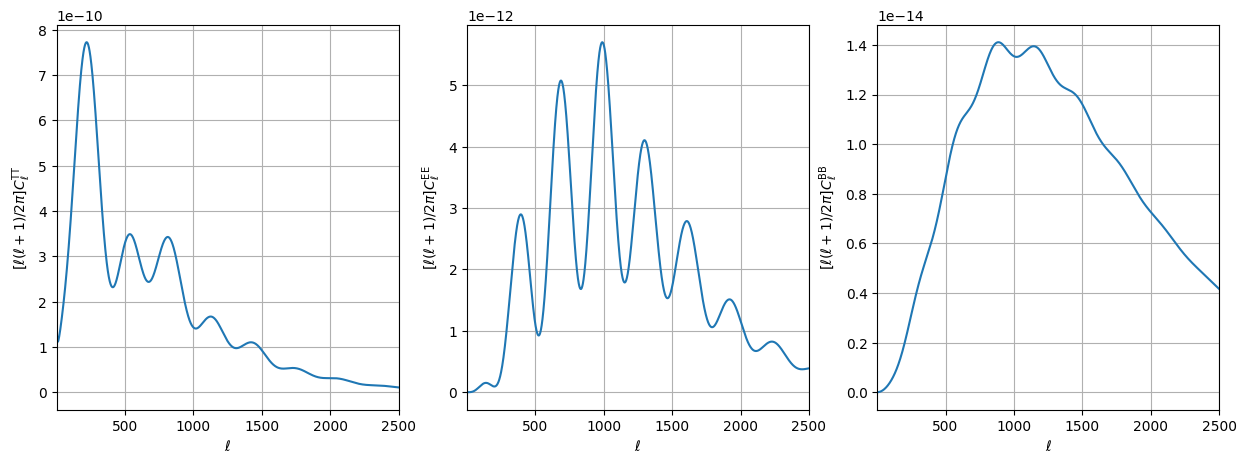

In [10]:
# plot C_l^TT
plt.figure(figsize=(15,5))
plt.subplot(131 )
plt.xscale('linear');plt.yscale('linear');plt.xlim(2,2500)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$[\ell(\ell+1)/2\pi]  C_\ell^\mathrm{TT}$')
plt.plot(ll,clTT*ll*(ll+1)/(2.*np.pi) )
plt.grid(True)

plt.subplot(132 )
plt.xscale('linear');plt.yscale('linear');plt.xlim(2,2500)
plt.ylabel(r'$[\ell(\ell+1)/2\pi]  C_\ell^\mathrm{EE}$')
plt.grid(True)

plt.xlabel(r'$\ell$')
plt.plot(ll,clEE*ll*(ll+1)/(2.*np.pi) )
plt.subplot(133 )
plt.xscale('linear');plt.yscale('linear');plt.xlim(2,2500)
plt.ylabel(r'$[\ell(\ell+1)/2\pi]  C_\ell^\mathrm{BB}$')
plt.xlabel(r'$\ell$')
plt.plot(ll,clBB*ll*(ll+1)/(2.*np.pi) )
plt.grid(True)

In [11]:
import healpy as hp

cmb_map = hp.synfast(cls['tt'] ,nside=1024, new=False  )

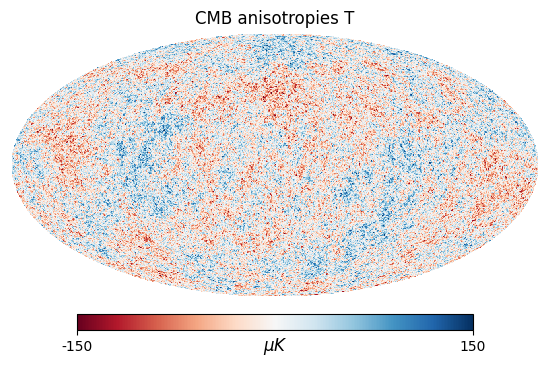

In [12]:
plt.figure(figsize=(8,10))

hp.mollview(cmb_map*1e6, cmap='RdBu', min=-150,max=150, title='CMB anisotropies T', unit=r'$\mu K$',sub=311  )


-1.086859979769625e-12


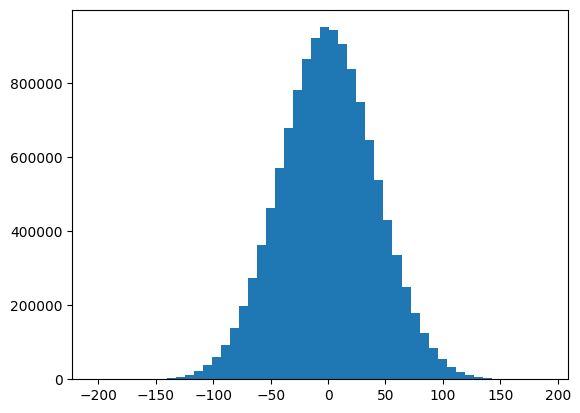

In [16]:
plt.hist(cmb_map*1e6, bins=50 ); print(cmb_map.mean() )

In [17]:
cl_obs = hp.anafast(cmb_map, lmax= ll.max()  )

In [18]:
cl_obs.size, ll.size, ll.max()

(2501, 2501, np.int64(2500))

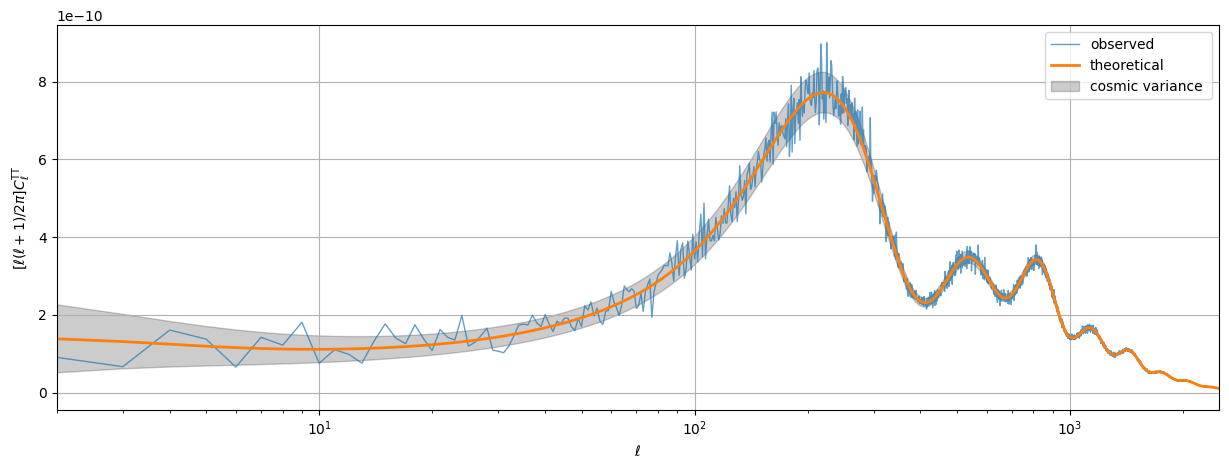

In [21]:
plt.figure(figsize=(15,5))

plt.xscale('log');plt.yscale('linear');plt.xlim(2,2500)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$[\ell(\ell+1)/2\pi]  C_\ell^\mathrm{TT}$')
plt.plot(ll, cl_obs *ll*(ll+1)/(2.*np.pi), alpha=.7,lw=1,label='observed')
plt.plot(ll,clTT*ll*(ll+1)/(2.*np.pi), lw=2, label='theoretical' )

plt.fill_between(ll,clTT* (1-  np.sqrt(2/(2*ll+1)))*ll*(ll+1)/(2.*np.pi), clTT* (1+ np.sqrt(2/(2*ll+1)))*ll*(ll+1)/(2.*np.pi), alpha=.2, color='k' , label='cosmic variance ' )
plt.legend()
plt.grid(True)

In [25]:
kk = np.geomspace(1e-4,3.0,num=1000) # k in h/Mpc
h = cosmo.h() # get reduced Hubble for conversions to h/Mpc
# Note that kk*h is the array of k in 1/Mpc
Pk = cosmo.get_pk_all(kk*h,z=0.)*h**3 # get power spectrum, converted into (Mpc/h)^3 units, instead of the default Mpc^3 units
Pklin  = cosmo.get_pk_all(kk*h,0, nonlinear=False )*h**3 # get power spectrum, converted into (Mpc/h)^3 units, instead of the default Mpc^3 units
# By default, this is the non-linear matter power spectrum; to get the linear one,
# pass the optional argument 'nonlinear=False' to .get_pk_all()

CosmoSevereError: 

Error in Class: fourier_pk_at_z(L:140) :condition (pfo->ln_tau_size == 1) is true; You are asking for the matter power spectrum at z=1.000000e-01 but the code was asked to store it only at z=0. You probably forgot to pass the input parameter z_max_pk (see explanatory.ini)

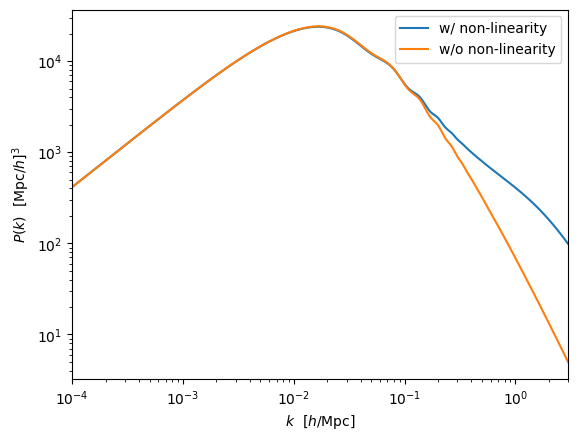

In [24]:
# plot P(k)
plt.figure(2)
plt.xscale('log');plt.yscale('log');plt.xlim(kk[0],kk[-1])
plt.xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$')
plt.ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/h]^3$')
plt.plot(kk,Pk,label='w/ non-linearity')
plt.plot(kk,Pklin,label='w/o non-linearity')
plt.legend()

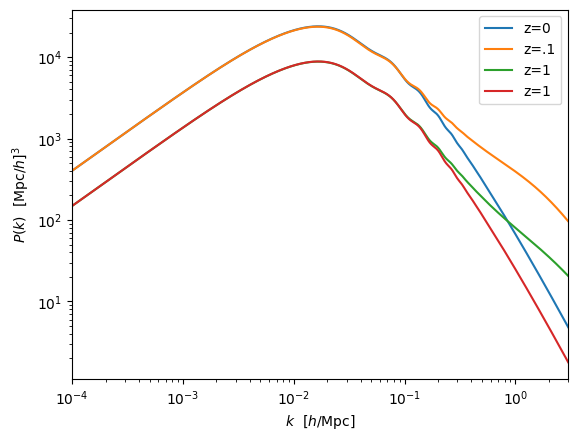

In [31]:
# plot P(k)
Pk0 = cosmo.get_pk_all(kk*h,z=0., nonlinear=False )*h**3 # get power spectrum, converted into (Mpc/h)^3 units, instead of the default Mpc^3 units
Pk0p1 = cosmo.get_pk_all(kk*h,z=0.)*h**3 # get power spectrum, converted into (Mpc/h)^3 units, instead of the default Mpc^3 units
Pk1 = cosmo.get_pk_all(kk*h,z=1.)*h**3 # get power spectrum, converted into (Mpc/h)^3 units, instead of the default Mpc^3 units
Pk1lin = cosmo.get_pk_all(kk*h,z=1., nonlinear=False)*h**3 # get power spectrum, converted into (Mpc/h)^3 units, instead of the default Mpc^3 units
plt.figure(2)
plt.xscale('log');plt.yscale('log');plt.xlim(kk[0],kk[-1])
plt.xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$')
plt.ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/h]^3$')
plt.plot(kk,Pk0,label='z=0')
plt.plot(kk,Pk0p1,label='z=.1')
plt.plot(kk,Pk1,label='z=1')
plt.plot(kk,Pk1lin,label='z=1')

plt.legend()